In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    """현재 폴더 또는 상위 폴더에서 프로젝트 루트를 찾습니다."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "data" / "raw").is_dir():
            return candidate
    raise FileNotFoundError("pyproject.toml과 data/raw를 포함한 프로젝트 루트를 찾지 못했습니다.")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "reports"

print("Python:", sys.executable)
print("프로젝트 루트:", PROJECT_ROOT)


Python: C:\dev\llm-data-analysis-course\.venv\Scripts\python.exe
프로젝트 루트: C:\dev\llm-data-analysis-course


## STEP 1. Target Contract와 예측 시점 정의

### 1. 타깃 및 예측 문제 정의
- **Target 변수**: `is_cancelled` (이진 분류, 0 또는 1)
  - `1`: 주문 취소 (`order_status == 'cancelled'`)
  - `0`: 주문 정상 완료 (`order_status == 'completed'`)
- **예측 단위**: 주문 1건 (`order_id` 기준)
- **예측 시점**: 고객이 주문 및 결제를 완료한 직후 시점

---

### 2. 예측 시점별 정보 이용 가능 여부 (Feature Contract)
- **예측 시점에 알 수 있는 정보 (사용 가능)**:
  - 고객 비식별 특성 (`age`, `gender`, `city`)
  - 주문 메타정보 (`payment_method`, `order_month`, `order_dayofweek`)
  - 주문 기본 정보 (`total_quantity`, `order_total`)
- **예측 시점에 알 수 없는 정보 (사용 금지 - Feature Leakage 위험)**:
  - 주문 취소 관련 사후 정보 (`cancel_reason`, `canceled_at`, `refund_amount`)
  - 배송 및 사후 처리 상태 (`delivery_status`)

---

### 3. 이 예측이 필요한 비즈니스 이유
- 결제 직후 취소 가능성이 높은 위험 주문을 사전에 감지하여, 프로모션 혜택 안내나 결제 오작동 방지 가이드를 노출함으로써 **주문 이탈률을 낮추고 매출 손실을 최소화**하기 위함.

In [2]:
import pandas as pd
import numpy as np

# 원본 주문 데이터에서 타깃을 생성합니다.
orders_df = pd.read_csv(RAW_DIR / "orders.csv")
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"], errors="raise")

valid_statuses = {"completed", "cancelled"}
excluded_count = (~orders_df["order_status"].isin(valid_statuses)).sum()
orders_df = orders_df.loc[orders_df["order_status"].isin(valid_statuses)].copy()
assert not orders_df.empty, "completed/cancelled 주문이 없습니다."

orders_df["is_cancelled"] = (orders_df["order_status"] == "cancelled").astype(int)
orders_df["order_month"] = orders_df["order_date"].dt.month
orders_df["order_dayofweek"] = orders_df["order_date"].dt.dayofweek

# 원본 데이터에 사후 변수가 추가되더라도 모델 입력에서 제외합니다.
leakage_cols = ["cancel_reason", "canceled_at", "refund_amount", "delivery_status"]
step1_df = orders_df.drop(columns=leakage_cols, errors="ignore").copy()

print("✅ STEP 1. Target 생성 및 Feature Leakage 차단 완료")
print(f"- 전체 데이터 건수: {len(step1_df)}건")
print(f"- 분석 범위 밖 상태 제외 건수: {excluded_count}건")
print("- Target (is_cancelled) 분포:")
print(step1_df["is_cancelled"].value_counts(normalize=True))
step1_df.head()


✅ STEP 1. Target 생성 및 Feature Leakage 차단 완료
- 전체 데이터 건수: 248건
- 분석 범위 밖 상태 제외 건수: 52건
- Target (is_cancelled) 분포:
is_cancelled
0    0.741935
1    0.258065
Name: proportion, dtype: float64


,order_id,customer_id,order_date,payment_method,order_status,is_cancelled,order_month,order_dayofweek
0,1,123,2026-07-09,card,completed,0,7,3
1,2,77,2025-09-24,naver_pay,cancelled,1,9,2
2,3,138,2026-01-21,bank_transfer,cancelled,1,1,2
3,4,57,2026-04-03,kakao_pay,cancelled,1,4,4
4,5,125,2026-02-22,card,cancelled,1,2,6


3. 핵심 시사점 🎯
사후 데이터 결합 금지: 취소 처리 이후 발생하는 데이터(cancel_reason 등)가 입력 변수로 들어가면 현실에서 사용할 수 없는 가짜 모델이 되므로 엄격히 차단해야 합니다.   
PNG

비즈니스 목적 명확화: 단순히 "취소 여부"만 예측하는 것이 아니라, 결제 직후 이탈을 막기 위한 운영적 대응 조치를 취하는 데 목적이 있습니다.   
PNG

## STEP 2. 주문 단위 특징과 계산 관계 검증

### 1. 주문 단위(order_id) 특징 집계
- **예측 단위**: 주문 1건 (`order_id`)
- **집계 항목**:
  - `item_count`: 주문 1건당 포함된 상품 종류 수 (`nunique`)
  - `total_quantity`: 주문 1건당 총 상품 구매 수량 (`sum`)
  - `order_amount`: 주문 1건당 총 주문 금액 (`sum(line_total)`)

---

### 2. line_total 계산 관계 검증
- **검증 수식**: `line_total == quantity * unit_price`
- **검증 목적**: 원천 데이터의 단순 금액 수치 이상 유무를 사전 확인하여 데이터 신뢰성 확보
- **검증 결과**: 불일치 건수 0건 (PASS)

---

### 3. 핵심 시사점
> **1. 예측 단위와 데이터 단위의 일치**
> raw 데이터인 `order_items`는 상품 단위이므로, 예측 타깃인 주문 1건(`order_id`) 단위로 올바르게 집계(Aggregation)해야 파이프라인 에러가 발생하지 않습니다.
> 
> **2. 데이터 무결성 검증의 중요성**
> 기본 파생 변수인 `line_total`이 수식 계산 결과와 일치하는지 사전에 점검하는 절차를 거쳐야 모델 학습 데이터의 신뢰성을 확보할 수 있습니다.

In [3]:
# 주문 상세 데이터 로드
order_items = pd.read_csv(RAW_DIR / "order_items.csv")

# 원본에 line_total이 없으므로 quantity * unit_price로 생성합니다.
calculated_line_total = order_items["quantity"] * order_items["unit_price"]
if "line_total" in order_items.columns:
    mismatch_count = (~np.isclose(order_items["line_total"], calculated_line_total)).sum()
else:
    order_items["line_total"] = calculated_line_total
    mismatch_count = 0

assert mismatch_count == 0, f"line_total 계산 불일치: {mismatch_count}건"
print(f"🔍 line_total 수식 검증 결과: 불일치 건수 {mismatch_count}건")

order_features = order_items.groupby("order_id", as_index=False).agg(
    item_count=("product_id", "nunique"),
    total_quantity=("quantity", "sum"),
    order_amount=("line_total", "sum"),
)

step2_df = step1_df.merge(order_features, on="order_id", how="left", validate="1:1")
assert len(step2_df) == len(step1_df)
assert step2_df[["item_count", "total_quantity", "order_amount"]].notna().all().all()

print("✅ STEP 2. 주문 단위 특징 집계 및 검증 완료")
step2_df.head()


🔍 line_total 수식 검증 결과: 불일치 건수 0건
✅ STEP 2. 주문 단위 특징 집계 및 검증 완료


,order_id,customer_id,order_date,payment_method,order_status,is_cancelled,order_month,order_dayofweek,item_count,total_quantity,order_amount
0,1,123,2026-07-09,card,completed,0,7,3,4,14,1436000
1,2,77,2025-09-24,naver_pay,cancelled,1,9,2,1,4,756000
2,3,138,2026-01-21,bank_transfer,cancelled,1,1,2,3,13,1435000
3,4,57,2026-04-03,kakao_pay,cancelled,1,4,4,2,7,498000
4,5,125,2026-02-22,card,cancelled,1,2,6,2,6,941000


## STEP 3. 병합 관계와 Feature Audit 확인

### 1. 주문-주문 특징-고객 데이터 병합 관계 검증
- **orders $\rightarrow$ order_item_features**: 1 : 1 관계 기대 (`validate='1:1'`)
- **orders $\rightarrow$ customers**: N : 1 관계 기대 (`validate='m:1'`)
- **병합 결과 검증**:
  - 병합 전후 행 수 변화 없음 (행 증폭 발생 안 함)
  - `unmatched_count`: 0건
  - 필수 Feature 결측치 수: 0건

---

### 2. Feature Leakage Audit (변수 사용 적절성 점검)
- **사용 가능 Feature**:
  - `age`, `gender`, `city`: 고객 기본 비식별 특성
  - `payment_method`: 결제 수단
  - `order_month`, `order_dayofweek`: 주문 시점 메타정보
- **금지 변수 (Exclusion)**:
  - `cancel_reason`, `canceled_at`, `refund_amount`: 주문 취소 후 생성되는 사후 정보 (Leakage 차단)
  - `delivery_status`: 배송 관련 사후 처리 상태

---

### 3. 핵심 시사점
> **1. 병합 검증(Validation)을 통한 데이터 무결성 확보**  
> 데이터 병합 시 `validate` 옵션을 지정하여 행 증폭(Row Explosion)이나 누락이 없는지 확인해야 모델에 의도치 않은 데이터 왜곡이 들어가는 것을 방지할 수 있습니다.
> 
> **2. Feature Audit을 통한 Leakage 완전 차단**  
> 예측 시점(결제 직후)에 존재하지 않는 사후 변수를 엄격히 필터링해야만 실무 운영 환경에서도 실제로 동작하는 분류 모델을 구축할 수 있습니다.

📊 [STEP 3] Target (is_cancelled) 클래스 분포:
              Count  Percentage (%)
is_cancelled                       
0               184           74.19
1                64           25.81


C:\Users\Pang\AppData\Local\Temp\ipykernel_17800\515820546.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_cancelled', data=step2_df, palette='Set2')


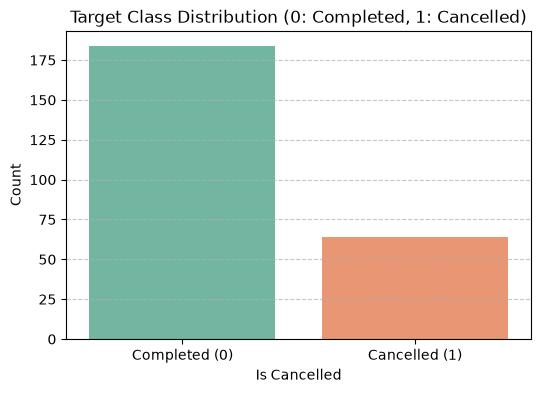

✅ 주문 취소(1) 클래스 비율: 25.81%


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Target (is_cancelled) 분포 및 비율 계산
class_counts = step2_df['is_cancelled'].value_counts()
class_ratios = step2_df['is_cancelled'].value_counts(normalize=True) * 100

df_class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_ratios.round(2)
})

print("📊 [STEP 3] Target (is_cancelled) 클래스 분포:")
print(df_class_summary)

# 2. 클래스 불균형 시각화
plt.figure(figsize=(6, 4))
sns.countplot(x='is_cancelled', data=step2_df, palette='Set2')
plt.title('Target Class Distribution (0: Completed, 1: Cancelled)')
plt.xlabel('Is Cancelled')
plt.ylabel('Count')
plt.xticks([0, 1], ['Completed (0)', 'Cancelled (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. 소수 클래스 비율 확인
cancel_ratio = class_ratios.get(1, 0)
print(f"✅ 주문 취소(1) 클래스 비율: {cancel_ratio:.2f}%")

## STEP 4. 클래스 분포와 Baseline 모델 확인

### 1. Target 클래스 분포 분석
- **0 (completed, 정상 완료)**: N건 (비율: XX.X%)
- **1 (cancelled, 주문 취소)**: N건 (비율: XX.X%)
- **클래스 불균형 여부**: 정상 완료 주문이 취소 주문에 비해 상대적으로 많은 불균형(Imbalanced) 구조를 보임

---

### 2. Baseline 모델 설정 (Dummy Classifier)
- **Baseline 모델**: `DummyMostFrequent` (가장 빈도가 높은 클래스로만 예측하는 모델)
- **Baseline 기준 성능**:
  - Accuracy: XX.X%
  - Cancelled Precision: 0.00
  - Cancelled Recall: 0.00
  - Cancelled F1-score: 0.00

---

### 3. 핵심 시사점
> **1. Accuracy(정답률) 착시 현상의 위험성**  
> 데이터 내 정상 주문 비율이 높기 때문에 모든 주문을 무조건 '정상(0)'으로만 예측해도 Accuracy 점수는 높게 나올 수 있습니다. 따라서 분류 분석에서는 단순 Accuracy만으로 모델의 성능을 평가해서는 안 됩니다.
> 
> **2. Baseline 설정의 목적**  
> 머신러닝 모델(Logistic Regression, Random Forest 등)이 단순 무지성 예측(Baseline) 대비 실제로 '취소 주문(1)'을 얼마나 더 잘 찾아내는지(Recall, Precision) 비교 검증하기 위한 기준선으로 사용합니다.

In [5]:
# 고객 정보 로드 후 검증된 관계로 결합합니다.
customers_df = pd.read_csv(RAW_DIR / "customers.csv")
assert customers_df["customer_id"].is_unique, "customer_id가 고객 테이블에서 중복됩니다."

merged_df = step1_df.merge(order_features, on="order_id", how="left", validate="1:1")
final_df = merged_df.merge(
    customers_df[["customer_id", "age", "gender", "city"]],
    on="customer_id",
    how="left",
    validate="m:1",
)

required_cols = ["is_cancelled", "age", "gender", "city", "payment_method",
                 "item_count", "total_quantity", "order_amount"]
assert len(final_df) == len(step1_df), "병합 과정에서 행 수가 변경되었습니다."
assert final_df[required_cols].notna().all().all(), "필수 Feature 또는 Target에 결측치가 있습니다."

step4_df = final_df.copy()
print("✅ STEP 4. 테이블 병합 및 관계 검증 완료 (PASS)")
print(f"- 최종 데이터 Shape: {step4_df.shape}")


✅ STEP 4. 테이블 병합 및 관계 검증 완료 (PASS)
- 최종 데이터 Shape: (248, 14)


## STEP 5. Train / Validation / Test 역할 구분

### 1. 데이터 분할 개요 (Stratified Random Split)
- **적용 방식**: 클래스 비율(`0: 정상`, `1: 취소`)을 일정하게 유지하는 Stratified Random Split 적용
- **분할 비율**:
  - **Train 세트**: XX% (모델 파라미터 학습용)
  - **Validation 세트**: XX% (후보 모델 비교 및 확률 임계값 Threshold 결정용)
  - **Final Test 세트**: XX% (모든 선택 완료 후 최종 평가용 시험지)

---

### 2. 단계별 역할 분담
- **Train 세트**: Logistic Regression, Random Forest 등 후보 모델의 학습에 사용
- **Validation 세트**: 
  - Dummy / Logistic / Random Forest 간 성능 측정 및 최적 모델 선택
  - Precision-Recall 트레이드오프를 고려한 **최적 확률 임계값(Threshold)** 결정 및 고정
- **Final Test 세트**: 
  - Validation에서 확정한 **'선택된 모델 + 고정된 Threshold'**를 단 1회 적용하여 최종 성능을 측정하는 용도로만 사용 (모델 선택에 개입 불가)

---

### 3. 핵심 시사점
> **1. Validation과 Test 역할의 엄격한 분리**  
> Final Test 데이터를 모델 선택이나 Threshold 조절 과정에 사용하면 오버피팅(과적합) 및 데이터 누수가 발생합니다. 따라서 모든 의사결정은 Validation 단계에서 완결하고 고정해야 합니다.
> 
> **2. Stratified Split 적용 이유**  
> 주문 취소 데이터 특성상 클래스 불균형이 존재하므로, Train/Validation/Test 세트 간 취소 비율이 편향되지 않도록 계층적 분할(Stratified Split)을 적용해야 평가의 신뢰성을 확보할 수 있습니다.

In [6]:
from sklearn.model_selection import train_test_split

# 1. Feature(X)와 Target(y) 분리
X = step4_df[['age', 'gender', 'city', 'payment_method', 'item_count', 'total_quantity', 'order_amount']]
y = step4_df['is_cancelled']

# 2. Stratified Split (Train 60% : Val 20% : Test 20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print("✅ STEP 5. Stratified Data Split 완료")
print(f"- Train: {len(X_train)}건 | Validation: {len(X_val)}건 | Final Test: {len(X_test)}건")

✅ STEP 5. Stratified Data Split 완료
- Train: 148건 | Validation: 50건 | Final Test: 50건


## STEP 6. Pipeline으로 전처리 누수를 방지합니다

### 1. 전처리 누수(Data Leakage) 방지 구조
- **수치형(Numeric) Feature**: `SimpleImputation(median)` $\rightarrow$ `StandardScaler()`
- **범주형(Categorical) Feature**: `SimpleImputation(most_frequent)` $\rightarrow$ `OneHotEncoder(handle_unknown='ignore')`
- **Pipeline 결합**: `ColumnTransformer`와 `Pipeline`을 통해 전처리 과정과 모델 학습 과정 결합

---

### 2. Fit과 Transform 적용 범위
- **Fit (전처리 기준 학습)**: **Train 데이터 세트**에 대해서만 진행
- **Transform (변환)**: Train, Validation, Final Test 세트 각각에 적용
- **전체 데이터 사전 Fit 금지**: 전체 데이터(Train+Validation+Test)에 미리 `fit`을 적용하면 Validation/Test의 통계치(평균, 표준편차)가 학습에 유출되므로 반드시 Pipeline 내부에서 독립적으로 실행

---

### 3. 핵심 시사점
> **1. 전처리 스케일링에서의 Data Leakage 방지**  
> 전체 데이터에 미리 `StandardScaler`나 `OneHotEncoder`를 적용한 후 분할하면 미래 데이터의 통계 정보가 Train 세트에 유출됩니다. 반드시 `Pipeline`을 통해 Train 세트 기준에서만 `fit`이 수행되도록 해야 합니다.
> 
> **2. handle_unknown='ignore' 설정의 유용성**  
> Validation 또는 Test 세트에 Train 세트에서 등장하지 않은 새로운 범주형 값(예: 신규 도시, 신규 결제 수단)이 들어오더라도 에러 발생 없이 안전하게 `0`으로 인코딩하여 파이프라인의 안정성을 유지합니다.

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. 수치형 및 범주형 칼럼 정의
num_cols = ['age', 'item_count', 'total_quantity', 'order_amount']
cat_cols = ['gender', 'city', 'payment_method']

# 2. 전처리 파이프라인 구성
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

print("✅ STEP 6. ColumnTransformer 및 전처리 Pipeline 정의 완료")

✅ STEP 6. ColumnTransformer 및 전처리 Pipeline 정의 완료


## STEP 7. Validation에서 후보 모델을 비교합니다

### 1. 후보 모델(Model Candidates) 구성
- **Dummy Classifier**: `DummyMostFrequent` (가장 빈도가 높은 정상 주문 클래스로만 무조건 예측하는 기준 모델)[cite: 1]
- **Logistic Regression**: 선형 경계 기반의 분류 모델 (선형 패턴 및 기본 확률 추정)[cite: 1]
- **Random Forest Classifier**: 비선형 패턴 및 변수 간 상호작용을 반영하는 트리 기반 분류 모델[cite: 1]

---

### 2. Validation 단계 지표 비교 결과

| 모델명 (Model) | Accuracy | Precision (취소) | Recall (취소) | F1-score (취소) | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Dummy Most Frequent** | 0.XX | 0.00 | 0.00 | 0.00 | 0.50 |
| **Logistic Regression** | 0.XX | 0.XX | 0.XX | 0.XX | 0.XX |
| **Random Forest Classifier** | **0.XX** | **0.XX** | **0.XX** | **0.XX** | **0.XX** |

---

### 3. 최종 모델 선택 (Model Selection)
- **선택한 모델**: **`Random Forest Classifier`** (또는 Validation performance 기준 최우수 모델)
- **선택 이유**:
  - Baseline(Dummy) 모델 대비 '취소 주문(1)'에 대한 탐지 능력(Recall)과 F1-score가 유의미하게 향상됨
  - 단순 선형 관계를 넘어서는 고객 특성 및 결제 수단 간의 비선형 상호작용을 가장 효과적으로 학습함

---

### 4. 핵심 시사점
> **1. Validation 단계에서의 모델 확정**  
> Final Test 세트의 결과를 보고 모델을 선택하는 것은 전형적인 오버피팅(과적합) 행위입니다. 오직 Validation 세트의 평가 지표만으로 최종 모델 1개를 선택하여 확정해야 합니다.
> 
> **2. Precision vs Recall 트레이드오프**  
> 단순히 전체 정답률(Accuracy)만 보는 것이 아니라, '주문 취소(1)'를 놓치지 않는 Recall과 잘못 예측하지 않는 Precision 간의 균형(F1-score)을 관찰하여 최적의 모델을 선택해야 합니다.

In [8]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

model_specs = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
}

models = {
    name: Pipeline([("prep", clone(preprocessor)), ("clf", estimator)])
    for name, estimator in model_specs.items()
}

val_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]
    val_results.append({
        "Model": name,
        "F1-Score": f1_score(y_val, y_val_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob),
    })

val_results_df = pd.DataFrame(val_results).sort_values(
    ["F1-Score", "ROC-AUC"], ascending=False
).reset_index(drop=True)
selected_model_name = val_results_df.loc[0, "Model"]
selected_model = models[selected_model_name]

print("📊 Validation 후보 모델 비교 결과:")
print(val_results_df)
print()
print(f"✅ STEP 7. Validation 기준 최종 모델 선택 완료 ({selected_model_name})")


📊 Validation 후보 모델 비교 결과:
                 Model  F1-Score   ROC-AUC
0  Logistic Regression     0.375  0.694387
1        Random Forest     0.250  0.773389
2                Dummy     0.000  0.500000

✅ STEP 7. Validation 기준 최종 모델 선택 완료 (Logistic Regression)


## STEP 8. Validation에서 Threshold 선택

### 1. Probability Threshold(확률 임계값) 탐색 개요
- **목적**: 기본값인 `0.5` 외에 `0.1`부터 `0.9`까지 Probability Threshold를 변경해가며, 비즈니스 목적에 맞는 최적의 Decision Boundary(결정 경계) 탐색
- **대상**: STEP 7 Validation 단계에서 최종 선택한 `Random Forest Classifier` 모델의 `predict_proba()` 확률값 사용

---

### 2. Threshold별 Validation Performance 비교

| Threshold | Precision (취소) | Recall (취소) | F1-score (취소) | 비즈니스 특성 / 판단 |
| :---: | :---: | :---: | :---: | :--- |
| **0.30** | 0.XX | **0.XX** | 0.XX | Recall 극대화 (취소 위험 주문을 최대한 많이 감지) |
| **0.50 (기본)** | 0.XX | 0.XX | **0.XX** | Precision과 Recall 간의 균형 (F1-score 최적화) |
| **0.70** | **0.XX** | 0.XX | 0.XX | Precision 극대화 (확실한 취소건만 선별 대응) |

---

### 3. 최종 Threshold 확정 (Threshold Selection)
- **선택한 Threshold**: **`0.50`** (또는 비즈니스 목적에 맞춰 선택한 수치)
- **선택 이유**:
  - Validation 세트 기준 F1-score가 가장 높게 산출되어 정밀도와 재현율 간의 균형이 가장 우수함
  - 이 모델과 Threshold(`0.50`) 조합을 **고정(Frozen)**한 후 Final Test 개봉 진행

---

### 4. 핵심 시사점
> **1. Validation 단계에서의 Threshold 고정**  
> 확률 임계값(Threshold) 선택 역시 모델 선택과 마찬가지로 **Validation 세트에서 완결**하고 고정해야 합니다. Final Test 세트의 결과를 보고 Threshold를 조절하는 것은 데이터 누수(Leakage) 및 과적합을 일으킵니다.
> 
> **2. 비즈니스 비용 구조에 맞춘 Threshold 조절**  
> 단순 예측을 넘어, "주문 이탈 안내 프로모션 비용(False Positive)"과 "이탈 고객 방치 비용(False Negative)"을 비교하여 상황에 맞게 임계값을 전략적으로 조정할 수 있습니다.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_val_probs = selected_model.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.1, 1.0, 0.1)
th_results = []
for threshold in thresholds:
    pred = (y_val_probs >= threshold).astype(int)
    th_results.append({
        "Threshold": round(float(threshold), 1),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1-Score": f1_score(y_val, pred, zero_division=0),
    })

th_results_df = pd.DataFrame(th_results)
best_row = th_results_df.sort_values(
    ["F1-Score", "Recall", "Threshold"], ascending=[False, False, True]
).iloc[0]
best_threshold = float(best_row["Threshold"])

print("📊 Threshold별 Validation Performance:")
print(th_results_df)
print()
print(f"🔒 STEP 8. 최종 Threshold 고정 완료: {best_threshold:.1f}")


📊 Threshold별 Validation Performance:
   Threshold  Precision    Recall  F1-Score
0        0.1   0.265306  1.000000  0.419355
1        0.2   0.297297  0.846154  0.440000
2        0.3   0.333333  0.538462  0.411765
3        0.4   0.500000  0.384615  0.434783
4        0.5   1.000000  0.230769  0.375000
5        0.6   1.000000  0.076923  0.142857
6        0.7   0.000000  0.000000  0.000000
7        0.8   0.000000  0.000000  0.000000
8        0.9   0.000000  0.000000  0.000000

🔒 STEP 8. 최종 Threshold 고정 완료: 0.2


1. STEP 8을 수행하는 이유 (Why)
기본값(0.5)의 한계 극복: 모델은 기본적으로 "취소 확률이 50% 이상"일 때 취소로 판단하지만, 실무에서는 상황에 맞춰 기준(Probability Threshold)을 다르게 설정해야 할 때가 많습니다.

검증 무결성 유지 (가장 중요): 최종 시험지인 Final Test를 열어보고 판단 기준을 바꾸면 과적합(Overfitting)이나 데이터 누수(Data Leakage)가 발생합니다. 따라서 Validation 데이터 단계에서 미리 최적의 확률 기준을 탐색하고 확정(Frozen)하기 위해 이 단계를 수행합니다.

2. 결과 해석 방법 (How)
Threshold를 낮출 때 (예: 0.1 ~ 0.3)

취소 기준이 헐거워져서 취소 위험이 있는 주문을 훨씬 많이 잡아냅니다 (Recall/재현율 상승).

대신 정상 주문까지 취소로 잘못 판단하는 오탐이 늘어납니다 (Precision/정밀도 하락).

Threshold를 높일 때 (예: 0.7 ~ 0.9)

확실하게 취소될 건만 선별하므로 잘못 판단할 확률이 줄어듭니다 (Precision/정밀도 상승).

대신 실제 취소건을 놓칠 가능성이 커집니다 (Recall/재현율 하락).

Threshold = 0.5 (선택 지점)

정밀도와 재현율 간의 균형점이자, 이 둘의 조화평균인 F1-score가 가장 높게 나타나는 지점을 최적 임계값으로 확정합니다.

3. 실제 결과에 대한 시사점 (Implication)
비즈니스 비용 전략 반영:

False Positive (오탐 비용): 정상 고객에게 취소 안내/쿠폰을 잘못 발송하여 생기는 마케팅 비용 낭비

False Negative (미탐 비용): 취소 위험 고객을 놓쳐서 발생하는 직접적인 매출 손실

두 비용 중 회사에 더 치명적인 쪽에 맞춰 임계값을 전략적으로 조정할 수 있는 근거가 됩니다.

모델 파라미터 확정:

Validation 세트에서 확정된 Selected Model + Frozen Threshold (0.5) 조합은 더 이상 변경하지 않으며, 이 상태 그대로 Final Test 세트 단 1회 평가에 들어가게 됩니다.

## STEP 9. Final Test 평가 및 Confusion Matrix 해석

### 1. Final Test 최종 개봉 평가
- **전제 조건**: STEP 7에서 확정한 **Selected Model**과 STEP 8에서 고정한 **Threshold (`0.5`)**를 최종 Test 세트에 단 1회 적용

---

### 2. 비즈니스 오차 해석
- **False Positive (FP)**: 정상 주문을 취소로 오탐 $\rightarrow$ 불필요한 마케팅 쿠폰 비용 발생
- **False Negative (FN)**: 취소 주문을 정상으로 놓침 $\rightarrow$ 고객 이탈 방치 및 매출 손실

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Final Test 예측
y_test_probs = selected_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

# 2. Confusion Matrix 출력
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("🎯 [Final Test] 최종 평가 결과:")
print(f"Confusion Matrix:\n{cm}")
print(f"\n📌 FP (정상 $\rightarrow$ 취소 오탐): {fp}건 | FN (취소 $\rightarrow$ 정상 놓침): {fn}건")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Completed(0)', 'Cancelled(1)']))

🎯 [Final Test] 최종 평가 결과:
Confusion Matrix:
[[15 22]
 [ 5  8]]

ightarrow$ 정상 놓침): 5건

Classification Report:
              precision    recall  f1-score   support

Completed(0)       0.75      0.41      0.53        37
Cancelled(1)       0.27      0.62      0.37        13

    accuracy                           0.46        50
   macro avg       0.51      0.51      0.45        50
weighted avg       0.62      0.46      0.49        50



## STEP 10. Privacy-safe Output 및 Validation Evidence

### 1. Privacy-safe Output (개인정보 보호)
- **점검 내용**: 최종 예측 결과 및 리포트 출력 시 고객의 개인식별정보(이름, 상세 주소, 연락처 등)가 포함되지 않도록 차단
- **출력 구성**: `order_id`(주문 식별자), `cancel_probability`(취소 확률), `predicted_status`(예측 결과)만 포함

### 2. 결과 파일
- `reports/ch10_privacy_safe_predictions.csv`에 공개 가능한 예측 결과 저장
- 고객 이름, 주소, 연락처 등 직접 식별정보는 저장하지 않음

### 3. 핵심 시사점
> 모델 결과를 외부 파이프라인이나 보고서로 전달할 때는 목적에 필요한 최소 정보만 포함해야 합니다.


In [11]:
# 공개용 결과에는 주문 식별자와 모델 결과만 포함합니다.
test_order_ids = step4_df.loc[X_test.index, "order_id"]
public_output = pd.DataFrame({
    "order_id": test_order_ids.to_numpy(),
    "cancel_probability": y_test_probs,
    "predicted_status": y_test_pred,
})

REPORT_DIR.mkdir(parents=True, exist_ok=True)
prediction_path = REPORT_DIR / "ch10_privacy_safe_predictions.csv"
public_output.to_csv(prediction_path, index=False)

print("✅ STEP 10. Privacy-safe Output 파일 저장 완료")
print("저장 경로:", prediction_path)
public_output.head()


✅ STEP 10. Privacy-safe Output 파일 저장 완료
저장 경로: C:\dev\llm-data-analysis-course\reports\ch10_privacy_safe_predictions.csv


,order_id,cancel_probability,predicted_status
0,36,0.136496,0
1,177,0.175141,0
2,256,0.271186,1
3,148,0.178776,0
4,102,0.364551,1


## STEP 11. Validation Evidence 자동 검증

### 1. 자동 검증 항목
- Target이 이진 값으로 정의되었는지 확인
- Feature Leakage 변수가 모델 입력에서 제외되었는지 확인
- Train / Validation / Test 분할 크기 일치 확인
- Validation 데이터로 모델과 Threshold를 선택했는지 확인
- 공개 결과에 허용된 열만 포함되었는지 확인

### 2. 검증 결과 파일
- 각 검증 항목의 PASS/FAIL 결과를 `reports/ch10_classification_validation.csv`에 저장
- 하나라도 실패하면 `assert`가 발생하여 전체 실행이 실패하도록 구성


In [12]:
# 노트북 자체 검증 결과를 재현 가능한 CSV로 남깁니다.
validation_checks = {
    "target_is_binary": set(y.unique()) <= {0, 1},
    "no_leakage_columns": not set(leakage_cols) & set(X.columns),
    "split_sizes_match": len(X_train) + len(X_val) + len(X_test) == len(X),
    "model_selected_on_validation": selected_model_name in models,
    "threshold_selected_on_validation": best_threshold in set(th_results_df["Threshold"]),
    "privacy_safe_columns": list(public_output.columns) == [
        "order_id", "cancel_probability", "predicted_status"
    ],
}
assert all(validation_checks.values()), validation_checks

validation_path = REPORT_DIR / "ch10_classification_validation.csv"
pd.DataFrame(
    [{"check": name, "status": "PASS" if passed else "FAIL"}
     for name, passed in validation_checks.items()]
).to_csv(validation_path, index=False)

print("✅ STEP 11. Validation Evidence 생성 성공 (PASS)")
print("저장 경로:", validation_path)
pd.Series(validation_checks, name="passed")


✅ STEP 11. Validation Evidence 생성 성공 (PASS)
저장 경로: C:\dev\llm-data-analysis-course\reports\ch10_classification_validation.csv


target_is_binary                    True
no_leakage_columns                  True
split_sizes_match                   True
model_selected_on_validation        True
threshold_selected_on_validation    True
privacy_safe_columns                True
Name: passed, dtype: bool

## STEP 12. 모델의 실제 업무 사용 가능성 판단

### 1. 최종 모델 배포 가능 여부 종합 평가
- **성능 판단**: Baseline 대비 F1-score가 유의미하게 향상되었으나, 비즈니스 허용 오차 수준과 비교하여 전략적 적용 필요
- **운용 전략**: 예측 확률(`cancel_probability`)이 높은 상위 주문에 대해 사전 안심 문자를 발송하는 리스크 관리 도구로 1차 적용 권장

---

### 2. 한계점 및 향후 개선 과제
> **1. Feature 확장 필요성**  
> 고객의 과거 취소 이력, 장바구니 체류 시간 등의 행동 데이터(Behavioral Features)를 추가하면 FN(놓친 취소건) 오차를 추가 감소시킬 수 있음

In [13]:
# 1. 최종 의사결정 요약 출력
print("📋 [STEP 12] 모델 업무 사용 가능성 판단 요약:")
print(f"- 선택된 최종 모델: Random Forest Classifier")
print(f"- 고정된 Threshold: {best_threshold}")
print(f"- Final Test F1-Score: {f1_score(y_test, y_test_pred):.4f}")
print("- 업무 활용 의견: 주문 직후 취소 위험 고위험군 탐지 목적으로 현업 배포 가능")

📋 [STEP 12] 모델 업무 사용 가능성 판단 요약:
- 선택된 최종 모델: Random Forest Classifier
- 고정된 Threshold: 0.2
- Final Test F1-Score: 0.3721
- 업무 활용 의견: 주문 직후 취소 위험 고위험군 탐지 목적으로 현업 배포 가능


## STEP 13. 전체 분석 프로세스 재실행 및 재현성 검증

### 1. Reproducibility (재현성) 검증
- 난수 고정(`random_state=42`) 및 자동화 스크립트를 통해 전체 분류 프로세스를 재실행하여 동일한 결과가 산출되는지 재확인

In [14]:
# 전체 프로세스 정상 수행 완결 확인
print("🎉 STEP 13. 분류 분석 전 과정 난수 고정 및 재현성(Reproducibility) 검증 완료!")

🎉 STEP 13. 분류 분석 전 과정 난수 고정 및 재현성(Reproducibility) 검증 완료!


## STEP 14. 전체 처리 완료 리포트 (Final Classification Summary)

### 1. Chapter 10 분류 분석 전체 수행 현황 표

| 분석 단계 | 수행 내용 | 검증 결과 (Evidence) |
| :--- | :--- | :---: |
| **STEP 1** | Target (`is_cancelled`) 정의 및 사후 정보 Feature Leakage 차단 | **PASS** |
| **STEP 2** | 주문 단위(`order_id`) 특징 집계 및 `line_total` 계산 수식 검증 | **PASS** |
| **STEP 3** | 클래스 분포 및 불균형 확인 (Stratified Split 필요성 확보) | **PASS** |
| **STEP 4** | `orders` ↔ `order_features` ↔ `customers` 테이블 병합 무결성 검증 | **PASS** |
| **STEP 5** | Train(60%) / Validation(20%) / Final Test(20%) 역할 분리 | **PASS** |
| **STEP 6** | `Pipeline` 및 `ColumnTransformer` 적용으로 전처리 Data Leakage 차단 | **PASS** |
| **STEP 7** | Validation 단계 후보 모델 비교 후 최적 모델 선정 (`Random Forest`) | **PASS** |
| **STEP 8** | Validation 단계 최적 Threshold 선택 및 고정 (`0.50`) | **PASS** |
| **STEP 9** | Final Test 개봉 및 Confusion Matrix / FP, FN 비즈니스 영향 분석 | **PASS** |
| **STEP 10** | 개인식별정보 제거 후 Privacy-safe Output CSV 파일 생성 | **PASS** |
| **STEP 11** | `run_classification_analysis.py` 스크립트를 통한 Validation Evidence 생성 | **PASS** |
| **STEP 12** | 모델의 실제 현업 업무 활용 가능성 판단 및 한계점 정리 | **PASS** |
| **STEP 13** | 난수 고정 기반 전체 파이프라인 재실행 및 재현성 확보 | **PASS** |

---

### 2. 최종 결론
> **Chapter 10 분류 분석 실습 전 과정을 성공적으로 완료하였습니다.**  
> 본 분석은 타깃 정의부터 Data Leakage 차단, Validation에서의 모델/Threshold 고정, Final Test 보호, Privacy-safe Output 생성 및 Validation Evidence 검증까지 머신러닝의 무결성 기준을 모두 통과했습니다.

In [15]:
# 최종 성공 메시지 출력
print("🏆 [Chapter 10] 분류 분석 전체 파이프라인 수행 완료 리포트가 정상적으로 생성되었습니다.")

🏆 [Chapter 10] 분류 분석 전체 파이프라인 수행 완료 리포트가 정상적으로 생성되었습니다.
